First cell: import libraries

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

Load the dataset

In [97]:
df = pd.read_csv("../data/ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Basic dataset inspection

In [98]:
print("Shape of the dataset:", df.shape )

Shape of the dataset: (10000, 14)


In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [100]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [101]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Check the target


In [102]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [103]:
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

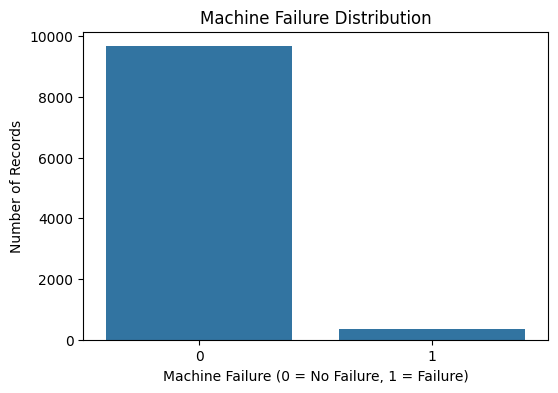

In [104]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Machine failure")

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure (0 = No Failure, 1 = Failure)")
plt.ylabel("Number of Records")

plt.show()

In [105]:
failure_types = ["TWF", "HDF", "PWF", "OSF", "RNF"]

df[failure_types].sum().sort_values(ascending=False)

HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

In [106]:
failure_summary = pd.DataFrame({
    "Failure Type": failure_types,
    "Count": [df[col].sum() for col in failure_types]
})

failure_summary

,Failure Type,Count
0,TWF,46
1,HDF,115
2,PWF,95
3,OSF,98
4,RNF,19


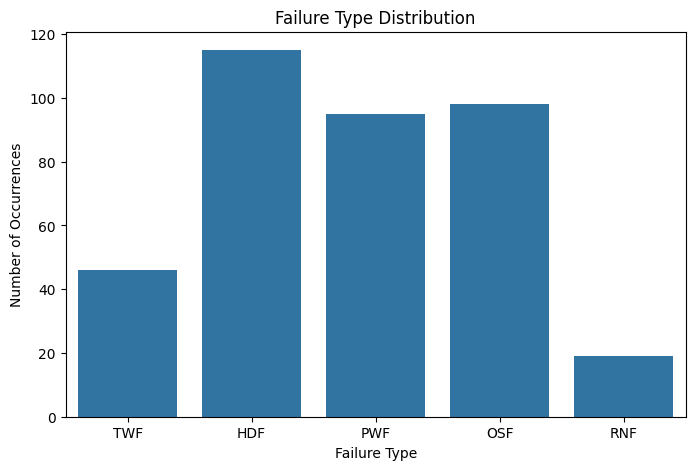

In [107]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=failure_summary,
    x="Failure Type",
    y="Count"
)

plt.title("Failure Type Distribution")
plt.xlabel("Failure Type")
plt.ylabel("Number of Occurrences")

plt.show()

Compare machine conditions for failure vs no failure

In [108]:
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df.groupby("Machine failure")[features].mean().T

Machine failure,0,1
Air temperature [K],299.973999,300.886431
Process temperature [K],309.995570,310.290265
Rotational speed [rpm],1540.260014,1496.486726
Torque [Nm],39.629655,50.168142
Tool wear [min],106.693717,143.781711


In [109]:
comparison = df.groupby("Machine failure")[features].mean().T

comparison["Difference"] = comparison[1] - comparison[0]

comparison

Machine failure,0,1,Difference
Air temperature [K],299.973999,300.886431,0.912432
Process temperature [K],309.995570,310.290265,0.294696
Rotational speed [rpm],1540.260014,1496.486726,-43.773289
Torque [Nm],39.629655,50.168142,10.538486
Tool wear [min],106.693717,143.781711,37.087994


Correlation with Machine Failure


In [110]:
correlation = df[[
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Machine failure"
]].corr()

correlation["Machine failure"].sort_values(ascending=False)

Machine failure            1.000000
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64

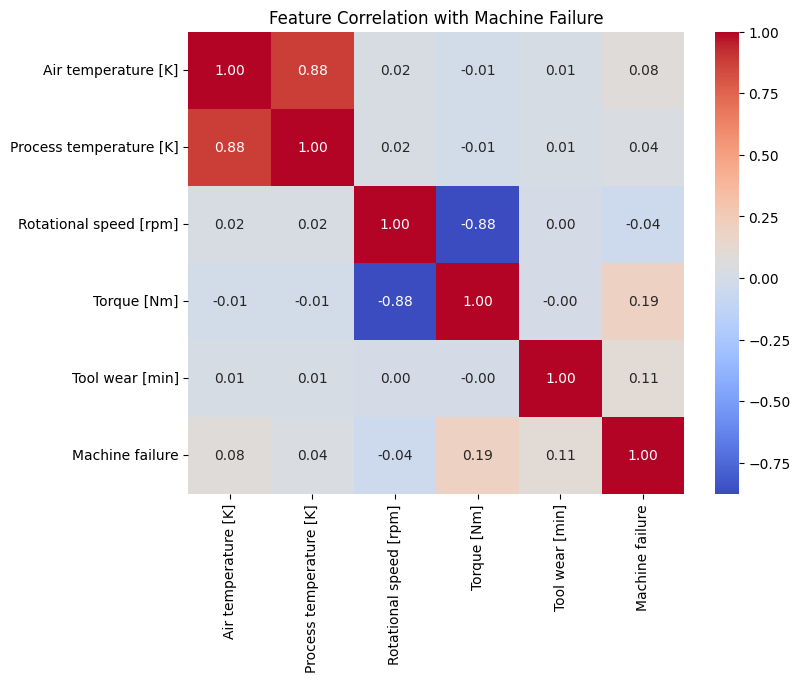

In [111]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation with Machine Failure")
plt.show()

Sensor distributions

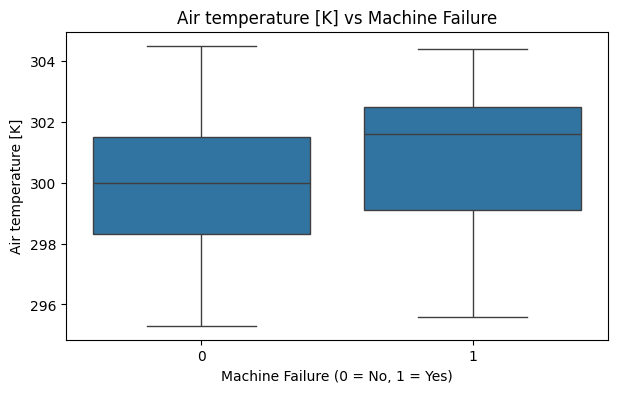

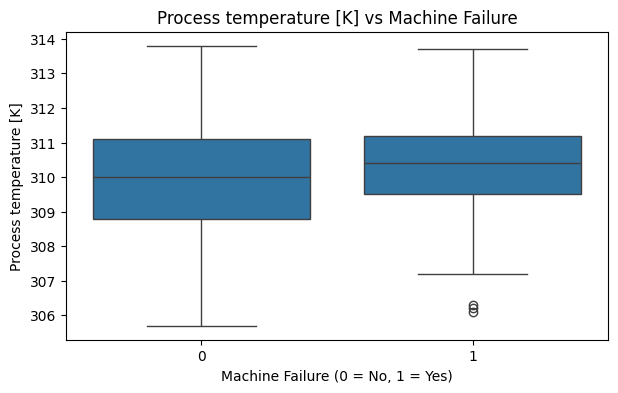

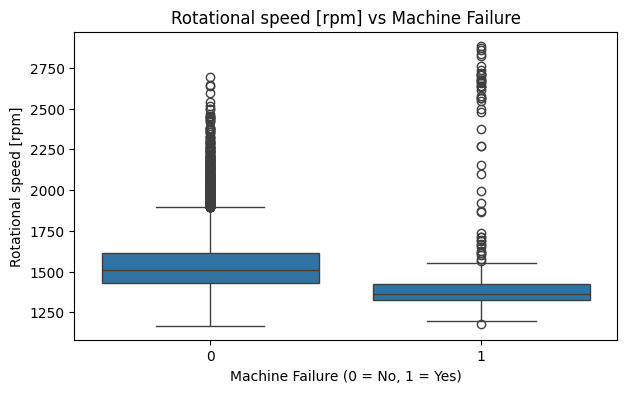

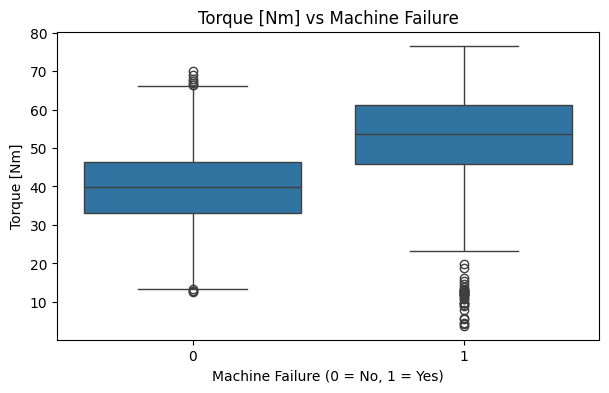

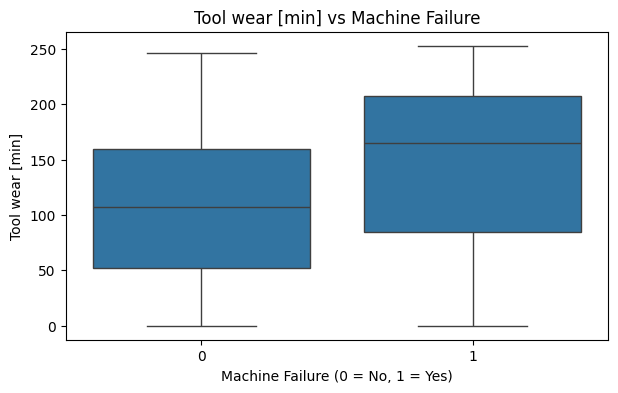

In [112]:
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for feature in features:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x="Machine failure",
        y=feature
    )

    plt.title(f"{feature} vs Machine Failure")
    plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
    plt.ylabel(feature)

    plt.show()

Check duplicates

In [113]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [114]:
df.dtypes


UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [115]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Create a copy

In [116]:
data = df.copy()
data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [117]:
data.shape

(10000, 14)

In [118]:
data = data.drop(columns=["UDI", "Product ID"])

In [119]:
data.shape

(10000, 12)

In [120]:
data.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Encode Type
Our ML models need numerical input. Type contains L, M, H.

We'll use one-hot encoding:

In [121]:
data = pd.get_dummies(
    data,
    columns=["Type"],
    drop_first=True,
    dtype=int
)

data.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,0,1
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,1,0
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,1,0
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,1,0
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,1,0


Separate features and target
For our failure prediction model:

In [122]:
X = data.drop(columns=["Machine failure"])
y = data["Machine failure"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 12)
Target shape: (10000,)


Split the data
Because only 3.39% of the records are failures, we must use stratify=y. This keeps roughly the same failure percentage in both training and testing sets.

In [123]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=["Machine failure"])
y = data["Machine failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 12)
Testing data: (2000, 12)


In [124]:
print("Training failure distribution:")
print(y_train.value_counts())

print("\nTesting failure distribution:")
print(y_test.value_counts())

Training failure distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Testing failure distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64


Why 80/20?
10,000 records
       ↓
8,000 → Training
2,000 → Testing
The model learns from the training data and we evaluate it on the unseen test data.

Why stratify=y?

Without stratification, we might accidentally get too few failures in the test set.

With it:
Full dataset    ≈ 3.39% failures
Training        ≈ 3.39% failures
Testing         ≈ 3.39% failures

For our main failure prediction model, let's use only information that represents the machine's operating condition:
Type
Air temperature
Process temperature
Rotational speed
Torque
Tool wear
So create the clean prediction dataset:

In [125]:
sensor_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Type_L",
    "Type_M"
]

X = data[sensor_features]
y = data["Machine failure"]

Split again

In [126]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (8000, 7)
X_test: (2000, 7)


feature scaling.
We'll scale only the continuous sensor features. This is needed for our first baseline model, Logistic Regression, because temperature, RPM, torque, and tool wear have very different numeric ranges.

In [127]:
from sklearn.preprocessing import StandardScaler

numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

X_test_scaled[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

X_train_scaled.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
4058,0.998914,0.604282,-0.460607,0.718305,-0.843997,0,1
1221,-1.505194,-1.153260,-0.775574,0.638456,0.382263,0,1
6895,0.498092,1.077466,-1.007654,0.558607,0.460870,0,1
9863,-0.553633,-0.139294,-0.709265,1.626586,-0.372359,1,0
8711,-1.455112,-1.018064,1.070019,-1.128202,-0.906882,1,0


Important: why fit_transform vs transform?
We do:

Training data → fit + transform
Testing data  → transform only
We never fit the scaler on test data, because that would allow information from the test set to influence training.

The Type_L and Type_M columns remain as 0/1.

In [128]:
X_train_scaled[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],8000.0,1.758593e-15,1.000063,-2.356591,-0.854126,0.047353,0.748503,2.250967
Process temperature [K],8000.0,1.053468e-14,1.000063,-2.910801,-0.815271,0.063500,0.739477,2.564616
Rotational speed [rpm],8000.0,3.010925e-16,1.000063,-2.052017,-0.648482,-0.200898,0.406932,7.441184
Torque [Nm],8000.0,-1.474376e-16,1.000063,-3.613500,-0.679052,0.009646,0.678380,3.652753
Tool wear [min],8000.0,-3.064216e-17,1.000063,-1.692947,-0.859719,-0.010769,0.869623,2.284539


Train Logistic Regression
We'll start with Logistic Regression. Not because it's necessarily our final/best model, but because it gives us a simple baseline that we can compare against stronger models later.

In [129]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


Why class_weight="balanced"?

Remember our dataset:

No failure → 96.61%
Failure    → 3.39%

If we train normally, the model can become biased toward the majority class.

class_weight="balanced" tells the model:

"Don't ignore the rare failure cases."

This is particularly important for our predictive-maintenance use case.

Make predictions

In [130]:
y_pred = logistic_model.predict(X_test_scaled)

y_probability = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions:", y_pred[:10])
print("Failure probabilities:", y_probability[:10])

Predictions: [1 1 1 0 1 1 1 0 0 1]
Failure probabilities: [0.9713345  0.53804762 0.68022315 0.01048656 0.85514666 0.6419895
 0.78092881 0.13001275 0.03976441 0.52523838]


evaluate the model

In [131]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("ROC-AUC Score:")
print(roc_auc_score(y_test, y_probability))

Classification Report:
              precision    recall  f1-score   support

           0     0.9925    0.8245    0.9008      1932
           1     0.1418    0.8235    0.2419        68

    accuracy                         0.8245      2000
   macro avg     0.5671    0.8240    0.5713      2000
weighted avg     0.9636    0.8245    0.8784      2000

Confusion Matrix:
[[1593  339]
 [  12   56]]
ROC-AUC Score:
0.9069160272804775


Random Forest

Now we'll train a Random Forest and see whether a nonlinear tree-based model performs better.

In [132]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


Notice we're using X_train rather than X_train_scaled.

That's intentional: Random Forest doesn't require feature scaling.

Then:

In [133]:
y_pred_rf = rf_model.predict(X_test)

y_probability_rf = rf_model.predict_proba(X_test)[:, 1]

In [134]:
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, digits=4))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("ROC-AUC Score:")
print(roc_auc_score(y_test, y_probability_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0     0.9827    0.9984    0.9905      1932
           1     0.9189    0.5000    0.6476        68

    accuracy                         0.9815      2000
   macro avg     0.9508    0.7492    0.8191      2000
weighted avg     0.9805    0.9815    0.9788      2000

Confusion Matrix:
[[1929    3]
 [  34   34]]
ROC-AUC Score:
0.960411338448423


Gradient Boosting

Let's test a third model that can potentially give us a better balance between recall and precision.

Gradient Boosting trained successfully!

========== CLASSIFICATION REPORT ==========

              precision    recall  f1-score   support

           0     0.9882    0.9974    0.9928      1932
           1     0.9000    0.6618    0.7627        68

    accuracy                         0.9860      2000
   macro avg     0.9441    0.8296    0.8777      2000
weighted avg     0.9852    0.9860    0.9850      2000


========== CONFUSION MATRIX ==========

[[1927    5]
 [  23   45]]


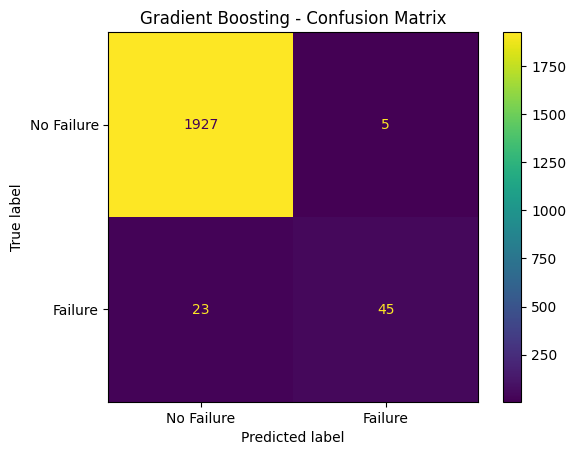


========== ROC-AUC ==========

ROC-AUC: 0.9681


In [135]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
# Train
gb_model.fit(X_train, y_train)
print("Gradient Boosting trained successfully!")
# Predictions
y_pred_gb = gb_model.predict(X_test)
y_probability_gb = gb_model.predict_proba(X_test)[:, 1]
# Evaluation
print("\n========== CLASSIFICATION REPORT ==========\n")
print(
    classification_report(
        y_test,
        y_pred_gb,
        digits=4
    )
)
# Confusion Matrix
cm_gb = confusion_matrix(y_test, y_pred_gb)
print("\n========== CONFUSION MATRIX ==========\n")
print(cm_gb)
ConfusionMatrixDisplay(
    confusion_matrix=cm_gb,
    display_labels=["No Failure", "Failure"]
).plot()

plt.title("Gradient Boosting - Confusion Matrix")
plt.show()

# ROC-AUC
roc_auc_gb = roc_auc_score(
    y_test,
    y_probability_gb
)

print("\n========== ROC-AUC ==========\n")
print(f"ROC-AUC: {roc_auc_gb:.4f}")

Gradient Boosting

It's giving us a much better balance than the other two.
Gradient Boosting catches 66.18% of actual failures.
That means it still misses 23 out of 68 failures.

Test different thresholds

In [136]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd
import numpy as np

# Test different probability thresholds
thresholds = np.arange(0.20, 0.71, 0.05)

results = []

for threshold in thresholds:

    # Convert probability into class prediction
    y_pred_threshold = (
        y_probability_gb >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    results.append({
        "Threshold": round(threshold, 2),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4)
    })

threshold_results = pd.DataFrame(results)

print("Threshold Performance:")
display(threshold_results)

Threshold Performance:


,Threshold,Precision,Recall,F1-Score
0,0.20,0.6395,0.8088,0.7143
1,0.25,0.7333,0.8088,0.7692
2,0.30,0.7846,0.7500,0.7669
3,0.35,0.7937,0.7353,0.7634
4,0.40,0.8596,0.7206,0.7840
5,0.45,0.8704,0.6912,0.7705
6,0.50,0.9000,0.6618,0.7627
7,0.55,0.9091,0.5882,0.7143
8,0.60,0.9250,0.5441,0.6852
9,0.65,0.9459,0.5147,0.6667


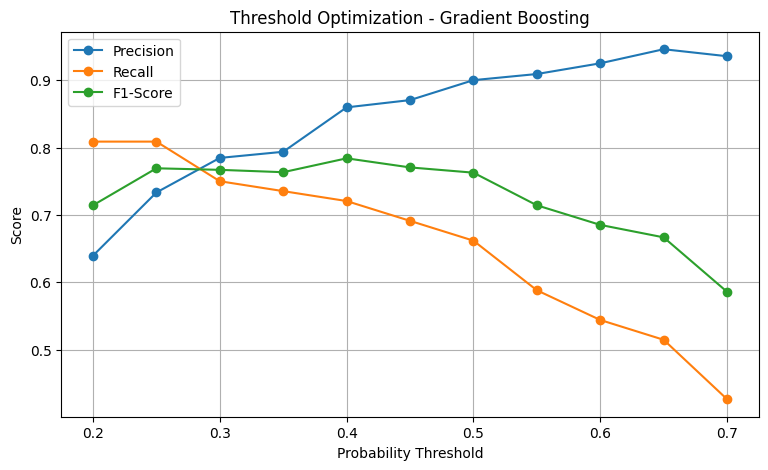

In [137]:
# PRECISION vs RECALL vs THRESHOLD

plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization - Gradient Boosting")
plt.legend()
plt.grid(True)

plt.show()

Anomaly Detection 
"Detects anomalies."

For this, we should use a separate anomaly-detection approach rather than treating Machine failure as the anomaly target.

We'll start with Isolation Forest, which is well suited to detecting unusual combinations of machine operating conditions.

Then we'll connect:

Sensor Data
    ↓
Isolation Forest
    ↓
Normal / Anomaly
    +
Gradient Boosting
    ↓
Failure Probability

Isolation Forest

In [138]:

# ANOMALY DETECTION - ISOLATION FOREST

from sklearn.ensemble import IsolationForest

# Create anomaly detector
anomaly_model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42,
    n_jobs=-1
)

# Train on the training data
anomaly_model.fit(X_train)

print("Isolation Forest trained successfully!")

Isolation Forest trained successfully!


Detect anomalies

In [139]:
# Isolation Forest returns:
#  1  = normal
# -1  = anomaly

anomaly_raw = anomaly_model.predict(X_test)

# Convert to easier format:
# 0 = normal
# 1 = anomaly

anomaly_prediction = (anomaly_raw == -1).astype(int)

print("Normal observations:", (anomaly_prediction == 0).sum())
print("Anomalies detected:", (anomaly_prediction == 1).sum())

Normal observations: 1946
Anomalies detected: 54


Add anomaly score

Isolation Forest also gives us a score indicating how unusual an observation is.

In [140]:
anomaly_score = -anomaly_model.decision_function(X_test)

print("First 10 anomaly scores:")
print(anomaly_score[:10])

First 10 anomaly scores:
[-0.09065358 -0.11926065 -0.12841808  0.00155678 -0.0559959  -0.09401382
 -0.15879002 -0.12092805 -0.14861866  0.02799448]


In [141]:
print("Total test observations:", len(X_test))
print("Normal observations:", (anomaly_prediction == 0).sum())
print("Anomalies detected:", (anomaly_prediction == 1).sum())

print("\nAnomaly percentage:")
print(f"{anomaly_prediction.mean() * 100:.2f}%")

Total test observations: 2000
Normal observations: 1946
Anomalies detected: 54

Anomaly percentage:
2.70%


In [142]:
contamination=0.03

In [143]:
anomaly_vs_failure = pd.crosstab(
    anomaly_prediction,
    y_test,
    rownames=["Anomaly"],
    colnames=["Machine Failure"]
)

anomaly_vs_failure

Machine Failure,0,1
Anomaly,,
0,1886,60
1,46,8


In [144]:
# ANOMALY DETECTION - CONTAMINATION COMPARISON
contamination_values = [0.01, 0.02, 0.03, 0.05, 0.08]

anomaly_results = []

for contamination in contamination_values:

    model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train)

    predictions = model.predict(X_test)
    predictions = (predictions == -1).astype(int)

    total_anomalies = predictions.sum()

    # How many actual failures were among detected anomalies?
    actual_failures_detected = y_test[predictions == 1].sum()

    anomaly_results.append({
        "Contamination": contamination,
        "Anomalies Detected": total_anomalies,
        "Anomaly %": round(
            total_anomalies / len(X_test) * 100, 2
        ),
        "Actual Failures Inside Anomalies": int(
            actual_failures_detected
        )
    })

anomaly_comparison = pd.DataFrame(anomaly_results)

display(anomaly_comparison)

,Contamination,Anomalies Detected,Anomaly %,Actual Failures Inside Anomalies
0,0.01,9,0.45,3
1,0.02,37,1.85,8
2,0.03,54,2.70,8
3,0.05,104,5.20,12
4,0.08,172,8.60,20


In [145]:
# FINAL ANOMALY DETECTOR - INITIAL CONFIG
anomaly_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

anomaly_model.fit(X_train)

anomaly_raw = anomaly_model.predict(X_test)

# 0 = Normal
# 1 = Anomaly
anomaly_prediction = (anomaly_raw == -1).astype(int)

# Higher value = more anomalous
anomaly_score = -anomaly_model.decision_function(X_test)

print("Anomaly detector trained successfully!")
print("Anomalies detected:", anomaly_prediction.sum())
print(f"Anomaly percentage: {anomaly_prediction.mean() * 100:.2f}%")

Anomaly detector trained successfully!
Anomalies detected: 104
Anomaly percentage: 5.20%


“Why did the model predict that this machine is at risk of failure?”

We'll use SHAP (SHapley Additive exPlanations) with our Gradient Boosting model.

SHAP Explainability

1. Install/import SHAP

In [146]:
%pip install shap -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [147]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


Create the SHAP explainer


In [148]:
# SHAP EXPLAINABILITY
explainer = shap.TreeExplainer(gb_model)

shap_values = explainer.shap_values(X_test)

print("SHAP values generated successfully!")
print("Shape:", np.array(shap_values).shape)

SHAP values generated successfully!
Shape: (2000, 7)


Overall feature importance

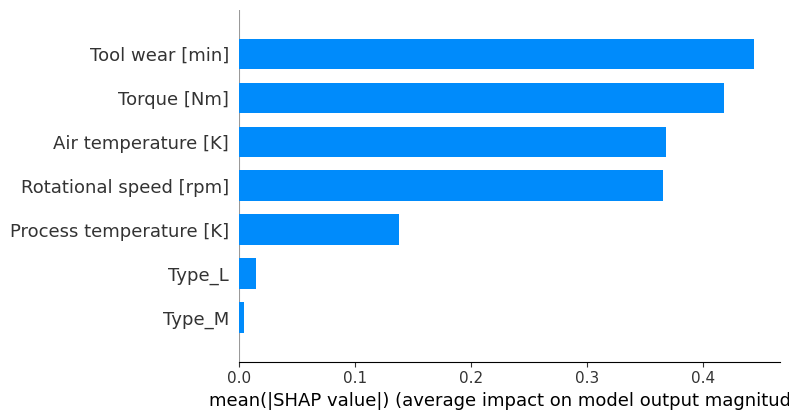

In [149]:
# GLOBAL FEATURE IMPORTANCE
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

See whether features increase/decrease risk
It helps us understand:

which features influence failure prediction
whether high/low feature values push risk upward or downward
which features have the strongest contribution

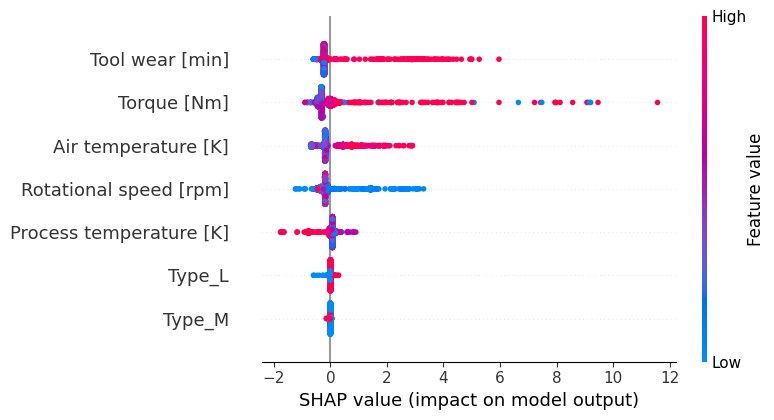

In [150]:
shap.summary_plot(
    shap_values,
    X_test
)

Explain one individual machine
Now let's select the machine with the highest predicted failure probability.

In [151]:
# INDIVIDUAL MACHINE EXPLANATION
highest_risk_index = np.argmax(y_probability_gb)

print("Test sample index:", highest_risk_index)
print(
    f"Failure probability: "
    f"{y_probability_gb[highest_risk_index] * 100:.2f}%"
)

print("\nMachine conditions:")
display(X_test.iloc[[highest_risk_index]])

Test sample index: 1189
Failure probability: 99.84%

Machine conditions:


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
8307,298.7,310.1,1402,69.7,64,0,1


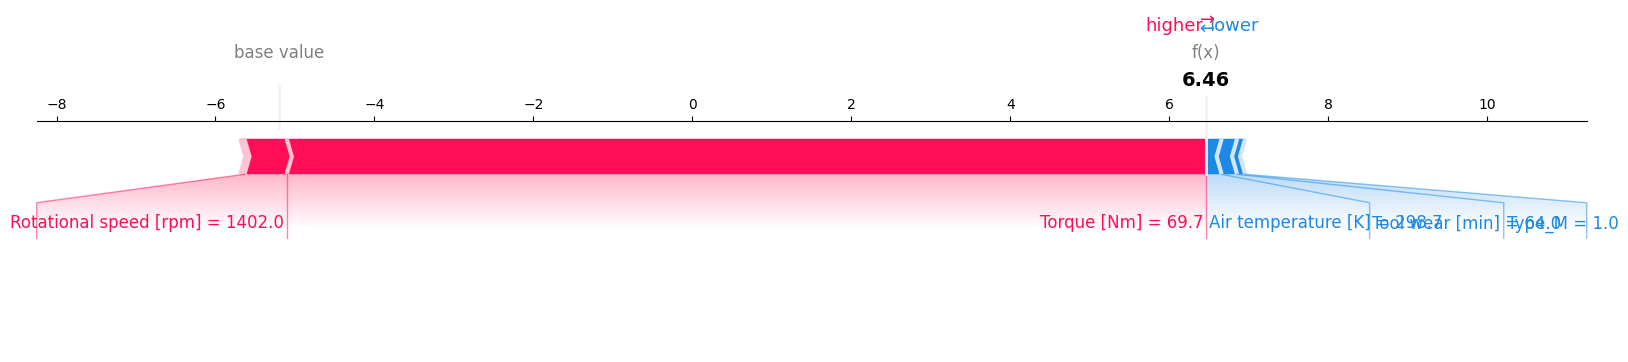

In [152]:
shap.force_plot(
    explainer.expected_value,
    shap_values[highest_risk_index],
    X_test.iloc[highest_risk_index],
    matplotlib=True
)

Better individual explanation

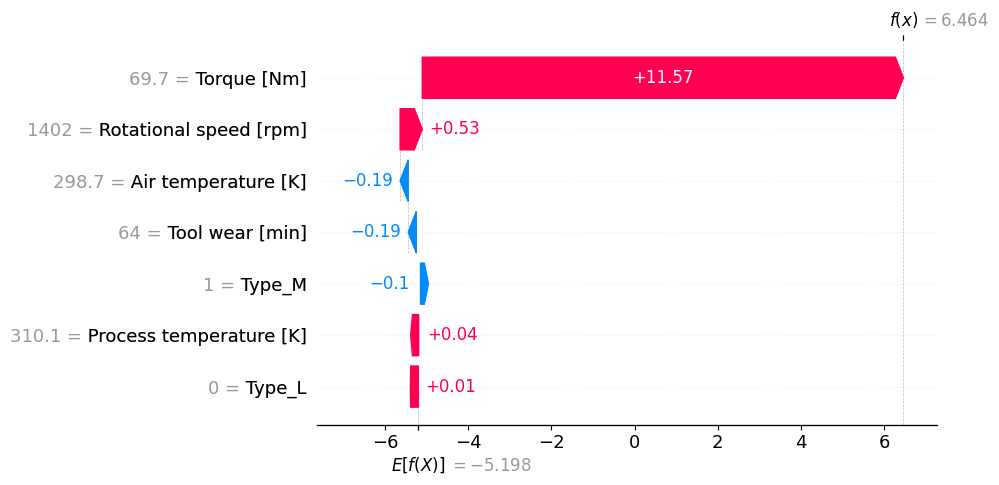

In [153]:
# INDIVIDUAL MACHINE - SHAP WATERFALL
# Select the highest-risk machine
highest_risk_index = np.argmax(y_probability_gb)

# Get SHAP values for that machine
sample_shap_values = shap_values[highest_risk_index]

# Make sure expected value is a single number
base_value = np.asarray(
    explainer.expected_value
).flatten()[0]

# Create SHAP explanation
sample_explanation = shap.Explanation(
    values=sample_shap_values,
    base_values=base_value,
    data=X_test.iloc[highest_risk_index].values,
    feature_names=X_test.columns.tolist()
)

# Display waterfall plot
shap.plots.waterfall(sample_explanation, max_display=10)

In [154]:
print("Highest-risk machine")
print("--------------------")

print(
    f"Failure probability: "
    f"{y_probability_gb[highest_risk_index] * 100:.2f}%"
)

print("\nMachine conditions:")
display(X_test.iloc[[highest_risk_index]])

Highest-risk machine
--------------------
Failure probability: 99.84%

Machine conditions:


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
8307,298.7,310.1,1402,69.7,64,0,1


get the actual top root causes

In [155]:
# TOP ROOT CAUSES FOR HIGHEST-RISK MACHINE
sample_shap = shap_values[highest_risk_index]

root_cause_df = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP_Value": sample_shap,
    "Machine_Value": X_test.iloc[highest_risk_index].values
})

root_cause_df["Absolute_Impact"] = root_cause_df["SHAP_Value"].abs()

root_cause_df = root_cause_df.sort_values(
    "Absolute_Impact",
    ascending=False
)

print("Top contributing factors:")
display(root_cause_df.head(5))

Top contributing factors:


,Feature,SHAP_Value,Machine_Value,Absolute_Impact
3,Torque [Nm],11.568622,69.7,11.568622
2,Rotational speed [rpm],0.532057,1402.0,0.532057
0,Air temperature [K],-0.194169,298.7,0.194169
4,Tool wear [min],-0.193978,64.0,0.193978
6,Type_M,-0.101634,1.0,0.101634


In [156]:
# Top 3 factors for GenAI
top_root_causes = root_cause_df.head(3)

print("Top 3 Root Causes:")
display(top_root_causes)

Top 3 Root Causes:


,Feature,SHAP_Value,Machine_Value,Absolute_Impact
3,Torque [Nm],11.568622,69.7,11.568622
2,Rotational speed [rpm],0.532057,1402.0,0.532057
0,Air temperature [K],-0.194169,298.7,0.194169


In [157]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
# Train
gb_model.fit(X_train, y_train)

print("Gradient Boosting trained successfully!")

# Predictions
y_pred_gb = gb_model.predict(X_test)
y_probability_gb = gb_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Gradient Boosting trained successfully!
Predictions generated successfully!


Machine_context


In [158]:
# Recreate structured machine context for GenAI

machine_context = {
    "failure_probability": round(
        float(y_probability_gb[highest_risk_index]), 4
    ),

    "risk_level": (
        "LOW" if y_probability_gb[highest_risk_index] < 0.40
        else "MEDIUM" if y_probability_gb[highest_risk_index] < 0.70
        else "HIGH" if y_probability_gb[highest_risk_index] < 0.90
        else "CRITICAL"
    ),

    "risk_threshold": 0.40,

    "anomaly_detected": False,

    "machine_conditions": {
        feature: float(
            X_test.iloc[highest_risk_index][feature]
        )
        for feature in X_test.columns
    },

    "top_contributing_factors": [
        {
            "feature": row["Feature"],
            "shap_value": round(
                float(row["SHAP_Value"]), 4
            ),
            "machine_value": float(
                row["Machine_Value"]
            )
        }
        for _, row in top_root_causes.iterrows()
    ]
}

machine_context

{'failure_probability': 0.9984,
 'risk_level': 'CRITICAL',
 'risk_threshold': 0.4,
 'anomaly_detected': False,
 'machine_conditions': {'Air temperature [K]': 298.7,
  'Process temperature [K]': 310.1,
  'Rotational speed [rpm]': 1402.0,
  'Torque [Nm]': 69.7,
  'Tool wear [min]': 64.0,
  'Type_L': 0.0,
  'Type_M': 1.0},
 'top_contributing_factors': [{'feature': 'Torque [Nm]',
   'shap_value': 11.5686,
   'machine_value': 69.7},
  {'feature': 'Rotational speed [rpm]',
   'shap_value': 0.5321,
   'machine_value': 1402.0},
  {'feature': 'Air temperature [K]',
   'shap_value': -0.1942,
   'machine_value': 298.7}]}

First create the GenAI prompt

In [159]:
def build_maintenance_prompt(machine_context):

    prompt = f"""
You are an AI maintenance assistant for a manufacturing plant.

Your job is to interpret the machine analysis provided below
and generate a safe, concise maintenance recommendation.

IMPORTANT RULES:

1. Do NOT predict a failure yourself.
2. Do NOT calculate or change the risk level.
3. Use the EXACT risk level and failure probability provided.
4. Use ONLY the information provided in the machine analysis.
5. Do NOT invent sensor values, causes, or maintenance history.
6. Treat SHAP factors as model contributors, NOT confirmed physical causes.
7. Recommend human maintenance review for high-risk situations.
8. Do NOT claim that a model contributor is a confirmed physical cause.
9. Keep recommendations practical and evidence-based.
10. The AI recommendation does NOT replace a qualified maintenance engineer.

MACHINE ANALYSIS:

Risk Level: {machine_context['risk_level']}

Failure Risk: {machine_context['failure_probability'] * 100:.2f}%

Risk Threshold: {machine_context['risk_threshold'] * 100:.0f}%

Anomaly Detected: {machine_context['anomaly_detected']}

Machine Conditions:
{machine_context['machine_conditions']}

Top Model-Contributing Factors:
{machine_context['top_contributing_factors']}

Generate the response in exactly this format:

Risk Level:
Failure Risk:
Anomaly Status:
Key Contributing Factors:
Recommended Action:
Priority:
Human Review Required:
Reason:
"""

    return prompt

In [160]:
genai_prompt = build_maintenance_prompt(machine_context)
print(genai_prompt)


You are an AI maintenance assistant for a manufacturing plant.

Your job is to interpret the machine analysis provided below
and generate a safe, concise maintenance recommendation.

IMPORTANT RULES:

1. Do NOT predict a failure yourself.
2. Do NOT calculate or change the risk level.
3. Use the EXACT risk level and failure probability provided.
4. Use ONLY the information provided in the machine analysis.
5. Do NOT invent sensor values, causes, or maintenance history.
6. Treat SHAP factors as model contributors, NOT confirmed physical causes.
7. Recommend human maintenance review for high-risk situations.
8. Do NOT claim that a model contributor is a confirmed physical cause.
9. Keep recommendations practical and evidence-based.
10. The AI recommendation does NOT replace a qualified maintenance engineer.

MACHINE ANALYSIS:

Risk Level: CRITICAL

Failure Risk: 99.84%

Risk Threshold: 40%

Anomaly Detected: False

Machine Conditions:
{'Air temperature [K]': 298.7, 'Process temperature [

Now Creating a gen Ai layer

Step1: install packages

In [161]:
%pip install openai python-dotenv -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Set your API key safely

In [162]:
%pip install -U google-genai python-dotenv -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [163]:
from pathlib import Path

root = Path(r"C:\Users\LENOVO\Desktop\Cognizant hackathon")

print("Files/folders in project root:")
for item in root.iterdir():
    print(" -", item.name)

print("\nSearching for .env:")
for item in root.rglob("*"):
    if item.name.lower().startswith(".env"):
        print("FOUND:", item)

Files/folders in project root:
 - Project

Searching for .env:
FOUND: C:\Users\LENOVO\Desktop\Cognizant hackathon\Project\ai\.env


In [164]:
import os
from pathlib import Path
from dotenv import load_dotenv

env_path = Path.cwd().parent / ".env"

print("Loading:", env_path)
print("Exists:", env_path.exists())

load_dotenv(env_path, override=True)

api_key = os.getenv("GEMINI_API_KEY")

print("API key loaded:", bool(api_key))
print("Key length:", len(api_key) if api_key else 0)
print("Key prefix:", api_key[:8] if api_key else None)

Loading: c:\Users\LENOVO\Desktop\Cognizant hackathon\Project\ai\.env
Exists: True
API key loaded: True
Key length: 53
Key prefix: AQ.Ab8RN


Initialize Gemini

In [165]:

from google import genai

client = genai.Client(api_key=api_key)

print("Gemini client ready!")

Gemini client ready!


Make the actual maintenance recommendation

In [166]:
y_probability_gb = gb_model.predict_proba(X_test)[:, 1]

In [167]:
print("y_probability_gb:", len(y_probability_gb))
print("X_test:", X_test.shape)

y_probability_gb: 2000
X_test: (2000, 7)


In [168]:
highest_risk_index = np.argmax(y_probability_gb)

print("Highest-risk index:", highest_risk_index)
print("Failure probability:",
      f"{y_probability_gb[highest_risk_index] * 100:.2f}%")

Highest-risk index: 1189
Failure probability: 99.84%


In [169]:
print("shap_values:", "OK" if "shap_values" in globals() else "MISSING")
print("root_cause_df:", "OK" if "root_cause_df" in globals() else "MISSING")
print("top_root_causes:", "OK" if "top_root_causes" in globals() else "MISSING")

shap_values: OK
root_cause_df: OK
top_root_causes: OK


In [172]:
import time

for attempt in range(3):
    try:
        response = client.models.generate_content(
            model="gemini-3.6-flash",
            
            contents=genai_prompt
        )
        print(response.text)
        break

    except Exception as e:
        if attempt < 2:
            wait_time = 2 ** attempt * 5
            print(f"Gemini temporarily unavailable. Retrying in {wait_time} seconds...")
            time.sleep(wait_time)
        else:
            print("Gemini request failed after 3 attempts.")
            print(e)

Gemini temporarily unavailable. Retrying in 5 seconds...
Risk Level: CRITICAL
Failure Risk: 99.84%
Anomaly Status: False
Key Contributing Factors: Torque [Nm] (69.7), Rotational speed [rpm] (1402.0), and Air temperature [K] (298.7) as model-contributing factors.
Recommended Action: Conduct an immediate physical inspection and evaluation of the machine, focusing on torque and speed parameters. Note: This AI recommendation does not replace a qualified maintenance engineer.
Priority: Immediate
Human Review Required: Yes
Reason: The failure risk is 99.84%, which severely exceeds the 40% risk threshold, resulting in a CRITICAL risk level that requires urgent human maintenance verification.


Combine ML + Anomaly + SHAP + GenAI

In [ ]:
# FINAL AI PIPELINE - COMBINE ALL COMPONENTS
def run_ai_pipeline(machine_context, maintenance_recommendation):

    failure_probability = machine_context["failure_probability"]
    
    # Risk level is already determined by our risk logic
    risk_level = machine_context["risk_level"]
    
    # Anomaly result comes from Isolation Forest
    anomaly_detected = machine_context["anomaly_detected"]
    
    # SHAP explanations
    top_contributing_factors = machine_context["top_contributing_factors"]

    # Final combined result
    final_result = {
        "failure_prediction": {
            "failure_probability": failure_probability,
            "failure_probability_percent": round(
                failure_probability * 100, 2
            )
        },

        "risk_assessment": {
            "risk_level": risk_level,
            "risk_threshold": machine_context["risk_threshold"]
        },

        "anomaly_detection": {
            "anomaly_detected": anomaly_detected
        },

        "explainability": {
            "top_contributing_factors": top_contributing_factors
        },

        "maintenance_recommendation": {
            "recommendation": maintenance_recommendation,
            "human_review_required": True
        }
    }

    return final_result

In [ ]:
final_ai_result = run_ai_pipeline(
    machine_context,
    maintenance_recommendation
)

final_ai_result

{'failure_prediction': {'failure_probability': 0.9984,
  'failure_probability_percent': 99.84},
 'risk_assessment': {'risk_level': 'CRITICAL', 'risk_threshold': 0.4},
 'anomaly_detection': {'anomaly_detected': False},
 'explainability': {'top_contributing_factors': [{'feature': 'Torque [Nm]',
    'shap_value': 11.5686,
    'machine_value': 69.7},
   {'feature': 'Rotational speed [rpm]',
    'shap_value': 0.5321,
    'machine_value': 1402.0},
   {'feature': 'Air temperature [K]',
    'shap_value': -0.1942,
    'machine_value': 298.7}]},
 'maintenance_recommendation': {'recommendation': "Risk Level: CRITICAL\n\nFailure Risk: 99.84%\n\nAnomaly Status: False\n\nKey Contributing Factors: Torque [Nm] (value: 69.7), Rotational speed [rpm] (value: 1402.0), and Air temperature [K] (value: 298.7) as model contributors (not confirmed physical causes).\n\nRecommended Action: Conduct an immediate physical inspection and human maintenance review of the machine, particularly assessing operating param

In [ ]:
print([name for name in globals() if "anomaly" in name.lower() or "forest" in name.lower()])

['RandomForestClassifier', 'IsolationForest', 'anomaly_model', 'anomaly_raw', 'anomaly_prediction', 'anomaly_score', 'anomaly_vs_failure', 'anomaly_results', 'anomaly_comparison']


In [ ]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

# Save trained models
joblib.dump(gb_model, "../models/failure_model.pkl")
joblib.dump(anomaly_model, "../models/anomaly_model.pkl")

print("Models saved successfully!")
print(os.listdir("../models"))

Models saved successfully!
['anomaly_model.pkl', 'failure_model.pkl', 'feature_config.pkl']


In [ ]:
import joblib
import os

# Save the exact feature order used by the model
feature_config = {
    "features": list(X_train.columns)
}

joblib.dump(
    feature_config,
    "../models/feature_config.pkl"
)

print("Feature configuration saved!")
print(feature_config["features"])

Feature configuration saved!
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L', 'Type_M']


In [ ]:
print(os.listdir("../models"))

['anomaly_model.pkl', 'failure_model.pkl', 'feature_config.pkl']


In [ ]:
import sys
from pathlib import Path

AI_DIR = Path.cwd().parent

if str(AI_DIR) not in sys.path:
    sys.path.insert(0, str(AI_DIR))

print(AI_DIR)

c:\Users\LENOVO\Desktop\Cognizant hackathon\Project\ai


In [ ]:
from explainability.explain import get_top_contributors

print("SHAP module imported successfully!")

SHAP module imported successfully!


In [ ]:
contributors = get_top_contributors(
    gb_model,
    X_test.iloc[[highest_risk_index]],
    top_n=3
)

contributors

[{'feature': 'Torque [Nm]', 'shap_value': 11.5686, 'machine_value': 69.7},
 {'feature': 'Rotational speed [rpm]',
  'shap_value': 0.5321,
  'machine_value': 1402.0},
 {'feature': 'Air temperature [K]',
  'shap_value': -0.1942,
  'machine_value': 298.7}]

In [ ]:
import sys
from pathlib import Path

AI_DIR = Path.cwd().parent

if str(AI_DIR) not in sys.path:
    sys.path.insert(0, str(AI_DIR))

In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

c:\Users\LENOVO\Desktop\Cognizant hackathon\Project


In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]

sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Python path:", sys.path[0])

Project root: c:\Users\LENOVO\Desktop\Cognizant hackathon\Project
Python path: c:\Users\LENOVO\Desktop\Cognizant hackathon\Project


In [ ]:
from pathlib import Path
import sys

print("Project root exists:", Path(PROJECT_ROOT).exists())
print("AI folder exists:", (PROJECT_ROOT / "ai").exists())
print("Pipeline exists:", (PROJECT_ROOT / "ai" / "pipeline.py").exists())
print("AI init exists:", (PROJECT_ROOT / "ai" / "__init__.py").exists())

import ai

print("Python is importing ai from:")
print(ai.__file__)

Project root exists: True
AI folder exists: True
Pipeline exists: True
AI init exists: True
Python is importing ai from:
C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\ai\__init__.py


In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path(r"C:\Users\LENOVO\Desktop\Cognizant hackathon\Project")

# Put our project first
sys.path.insert(0, str(PROJECT_ROOT))

# Remove previously loaded conflicting 'ai' package
if "ai" in sys.modules:
    del sys.modules["ai"]

import ai

print("AI package:", ai.__file__)

AI package: C:\Users\LENOVO\Desktop\Cognizant hackathon\Project\ai\__init__.py


In [ ]:
from ai.pipeline import run_ai_pipeline

print("AI pipeline imported successfully!")

AI pipeline imported successfully!


In [174]:
# Test machine input
test_machine = {
    "Air temperature [K]": 298.7,
    "Process temperature [K]": 310.1,
    "Rotational speed [rpm]": 1402.0,
    "Torque [Nm]": 69.7,
    "Tool wear [min]": 64.0,
    "Type": "L"
}

# Run complete AI pipeline
final_result = run_ai_pipeline(
    test_machine,
    client
)

print(final_result)

{'failure_prediction': {'failure_probability': 0.9986, 'failure_probability_percent': 99.86, 'risk_level': 'CRITICAL'}, 'anomaly_detection': {'anomaly_detected': False}, 'explainability': {'top_contributing_factors': [{'feature': 'Torque [Nm]', 'shap_value': 11.6649, 'machine_value': 69.7}, {'feature': 'Rotational speed [rpm]', 'shap_value': 0.5389, 'machine_value': 1402.0}, {'feature': 'Tool wear [min]', 'shap_value': -0.2856, 'machine_value': 64.0}]}, 'maintenance_recommendation': "Risk Level: CRITICAL\n\nFailure Risk: 99.86%\n\nAnomaly Status: False\n\nKey Contributing Factors: Torque [Nm] (Value: 69.7), Rotational speed [rpm] (Value: 1402.0), Tool wear [min] (Value: 64.0) — *Note: These are model-contributing factors based on SHAP analysis, not confirmed physical causes.*\n\nRecommended Action: Schedule an immediate on-site inspection by a qualified maintenance engineer to evaluate the machine's operating conditions, particularly checking torque and rotational speed. Do not treat m